<a href="https://colab.research.google.com/github/sanjxxn/ML-Lab-Exercises/blob/main/Sanjay_R_A_555_lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, StandardScaler

In [ ]:
df=pd.read_csv("heart.csv")


In [ ]:
df.shape

(918, 12)

In [ ]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  


In [ ]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [ ]:
print(f"\n Numerical Attributes ({len(num_cols)}):")
for col in num_cols:
  print(f" -{col}")
print(f"\n Categorical Attributes ({len(cat_cols)}):")
for col in cat_cols:
  print(f" -{col}")


 Numerical Attributes (7):
 -Age
 -RestingBP
 -Cholesterol
 -FastingBS
 -MaxHR
 -Oldpeak
 -HeartDisease

 Categorical Attributes (5):
 -Sex
 -ChestPainType
 -RestingECG
 -ExerciseAngina
 -ST_Slope


In [ ]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


In [ ]:
print("\nStatistical Summary")
print(df.describe().round(2))


Statistical Summary
          Age  RestingBP  Cholesterol  FastingBS   MaxHR  Oldpeak  \
count  918.00     918.00       918.00     918.00  918.00   918.00   
mean    53.51     132.40       198.80       0.23  136.81     0.89   
std      9.43      18.51       109.38       0.42   25.46     1.07   
min     28.00       0.00         0.00       0.00   60.00    -2.60   
25%     47.00     120.00       173.25       0.00  120.00     0.00   
50%     54.00     130.00       223.00       0.00  138.00     0.60   
75%     60.00     140.00       267.00       0.00  156.00     1.50   
max     77.00     200.00       603.00       1.00  202.00     6.20   

       HeartDisease  
count        918.00  
mean           0.55  
std            0.50  
min            0.00  
25%            0.00  
50%            1.00  
75%            1.00  
max            1.00  


In [ ]:
missing = df.isnull().sum()
print("\nMissing Values:\n{missing}")
if missing.sum() == 0:
  print("No missing values.")
else:
  df.fillna(df.median(numeric_only=True),inplace=True)
  print("Missing values are filled with medians.")


Missing Values:
{missing}
No missing values.


In [ ]:
duplicates = df.duplicated().sum()
print(f"\nDuplicate Records: {duplicates}")
if duplicates > 0:
  df.drop_duplicates(inplace=True)
  print("{duplicates}Duplicate records are dropped.")
else:
  print("No Duplicates are found.")
print(df.shape)


Duplicate Records: 0
No Duplicates are found.
(918, 12)


In [ ]:
zeros_chol = (df['Cholesterol'] == 0).sum()
print(f"\nRecords with Cholesterol = 0: {zeros_chol}")
zeros_bp = (df['RestingBP'] == 0).sum()
print(f"Records with RestingBP = 0: {zeros_bp}")


Records with Cholesterol = 0: 172
Records with RestingBP = 0: 1


In [ ]:
df['Cholesterol']=df['Cholesterol'].replace(0,np.nan)
df['RestingBP']=df['RestingBP'].replace(0,np.nan)

In [ ]:
chol_median = df.loc[df['Cholesterol'] != 0, 'Cholesterol'].median()
bp_median   = df.loc[df['RestingBP']   != 0, 'RestingBP'].median()
df['Cholesterol'] = df['Cholesterol'].where(df['Cholesterol'] != 0, chol_median)
df['RestingBP']   = df['RestingBP'].where(df['RestingBP']   != 0, bp_median)
print(f"Cholesterol records with value 0 are replaced with {chol_median}")
print(f"RestingBP records with value 0 are replaced with {bp_median}")

Cholesterol records with value 0 are replaced with 237.0
RestingBP records with value 0 are replaced with 130.0


In [ ]:
print(df.dtypes)

Age                 int64
Sex                object
ChestPainType      object
RestingBP         float64
Cholesterol       float64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object


In [ ]:
print(df.columns.tolist())

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']


In [ ]:
features = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak']

/tmp/ipykernel_15153/2232650984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= features, y=df[features].mean(),palette='muted')


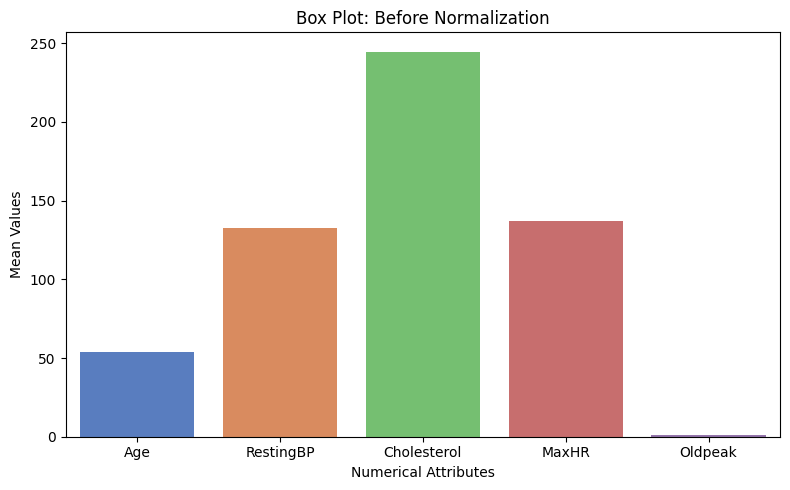

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x= features, y=df[features].mean(),palette='muted')
plt.title("Box Plot: Before Normalization")
plt.xlabel("Numerical Attributes")
plt.ylabel("Mean Values")
plt.tight_layout()
plt.show()

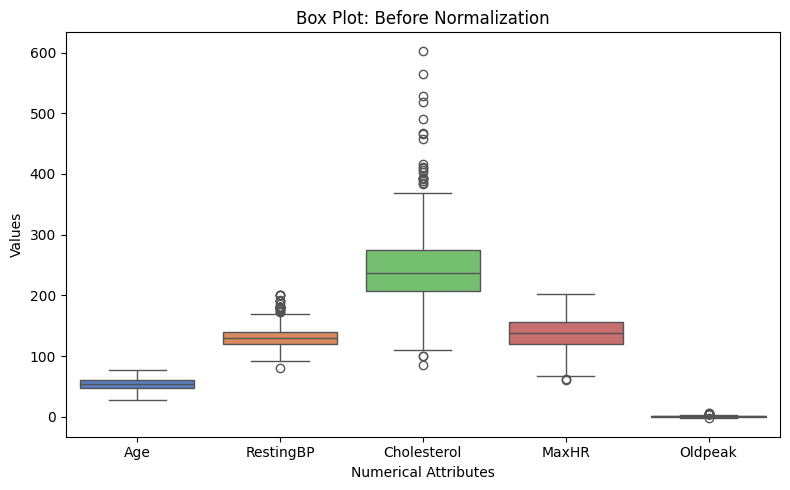

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[features],palette='muted')
plt.title("Box Plot: Before Normalization")
plt.xlabel("Numerical Attributes")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

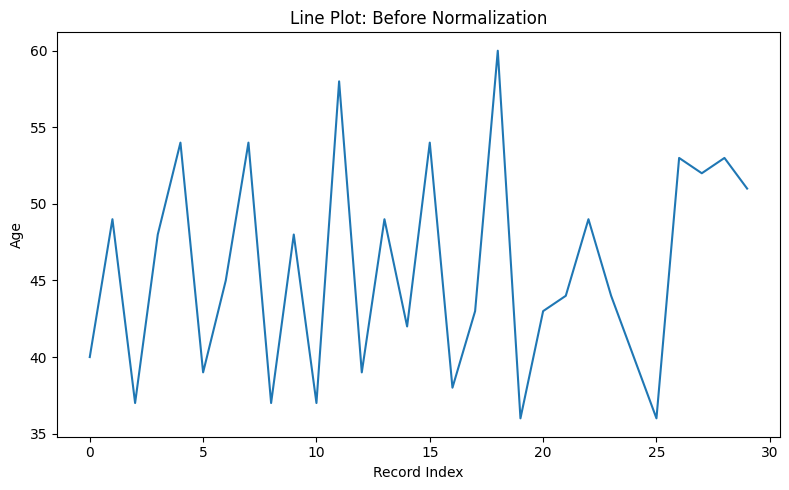

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(x=range(30), y=df['Age'].head(30))
plt.title("Line Plot: Before Normalization")
plt.xlabel("Record Index")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [ ]:
min_max_scaler = MinMaxScaler()
df_minmax = df.copy()
df_minmax[features] = min_max_scaler.fit_transform(df[features])

In [ ]:
print("\nOriginal vs Min-Max Normalized Data:")
comparison_mm = pd.concat([df[features].head(5).add_suffix('_Original'),df_minmax[features].head(5).add_suffix('_MinMax')],axis=1)
cols_ordered = []
for f in features:
    cols_ordered += [f+'_Original',f+'_MinMax']
print(comparison_mm[cols_ordered].round(4).to_string())


Original vs Min-Max Normalized Data:
   Age_Original  Age_MinMax  RestingBP_Original  RestingBP_MinMax  Cholesterol_Original  Cholesterol_MinMax  MaxHR_Original  MaxHR_MinMax  Oldpeak_Original  Oldpeak_MinMax
0            40      0.2449               140.0            0.5000                 289.0              0.3938             172        0.7887               0.0          0.2955
1            49      0.4286               160.0            0.6667                 180.0              0.1834             156        0.6761               1.0          0.4091
2            37      0.1837               130.0            0.4167                 283.0              0.3822              98        0.2676               0.0          0.2955
3            48      0.4082               138.0            0.4833                 214.0              0.2490             108        0.3380               1.5          0.4659
4            54      0.5306               150.0            0.5833                 195.0              0

In [ ]:
print("\nMin-Max Normalized Statistics:")
print(df_minmax[features].describe().round(4))


Min-Max Normalized Statistics:
            Age  RestingBP  Cholesterol     MaxHR   Oldpeak
count  918.0000   917.0000     746.0000  918.0000  918.0000
mean     0.5206     0.4378       0.3082    0.5409    0.3963
std      0.1925     0.1500       0.1142    0.1793    0.1212
min      0.0000     0.0000       0.0000    0.0000    0.0000
25%      0.3878     0.3333       0.2360    0.4225    0.2955
50%      0.5306     0.4167       0.2934    0.5493    0.3636
75%      0.6531     0.5000       0.3668    0.6761    0.4659
max      1.0000     1.0000       1.0000    1.0000    1.0000


In [ ]:
zscore_scaler=StandardScaler()
df_zscore=df.copy()
df_zscore[features]=zscore_scaler.fit_transform(df[features])

In [ ]:
print("\nOriginal vs Z-Score Normalized Data:")
comparison_zs = pd.concat([df[features].head(5).add_suffix('_Original'),df_zscore[features].head(5).add_suffix('_ZScore')],axis=1)
cols_ordered_zs=[]
for f in features:
    cols_ordered_zs += [f+'_Original',f+'_ZScore']
print(comparison_zs[cols_ordered_zs].round(4).to_string())


Original vs Z-Score Normalized Data:
   Age_Original  Age_ZScore  RestingBP_Original  RestingBP_ZScore  Cholesterol_Original  Cholesterol_ZScore  MaxHR_Original  MaxHR_ZScore  Oldpeak_Original  Oldpeak_ZScore
0            40     -1.4331               140.0            0.4146                 289.0              0.7505             172        1.3829               0.0         -0.8324
1            49     -0.4785               160.0            1.5264                 180.0             -1.0934             156        0.7542               1.0          0.1057
2            37     -1.7514               130.0           -0.1412                 283.0              0.6490              98       -1.5251               0.0         -0.8324
3            48     -0.5846               138.0            0.3035                 214.0             -0.5182             108       -1.1322               1.5          0.5747
4            54      0.0519               150.0            0.9705                 195.0             -0

In [ ]:
print("\nZ-Score Normalized Statistics:")
print(df_zscore[features].describe().round(4))


Z-Score Normalized Statistics:
            Age  RestingBP  Cholesterol     MaxHR   Oldpeak
count  918.0000   917.0000     746.0000  918.0000  918.0000
mean    -0.0000     0.0000      -0.0000    0.0000    0.0000
std      1.0005     1.0005       1.0007    1.0005    1.0005
min     -2.7060    -2.9206      -2.7005   -3.0185   -3.2715
25%     -0.6906    -0.6971      -0.6324   -0.6606   -0.8324
50%      0.0519    -0.1412      -0.1292    0.0468   -0.2696
75%      0.6883     0.4146       0.5137    0.7542    0.5747
max      2.4916     3.7498       6.0623    2.5619    4.9838


/tmp/ipykernel_15153/3664843132.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x= features, y=df_minmax[features].mean(),palette='muted')


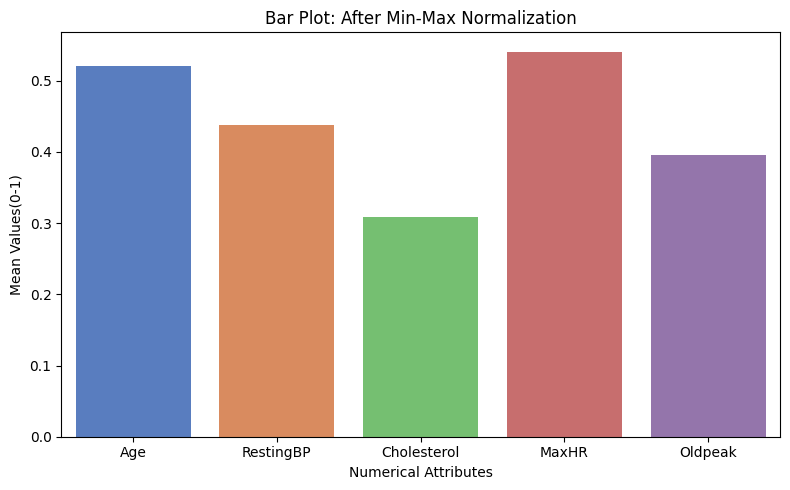

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x= features, y=df_minmax[features].mean(),palette='muted')
plt.title("Bar Plot: After Min-Max Normalization")
plt.xlabel("Numerical Attributes")
plt.ylabel("Mean Values(0-1)")
plt.tight_layout()
plt.show()

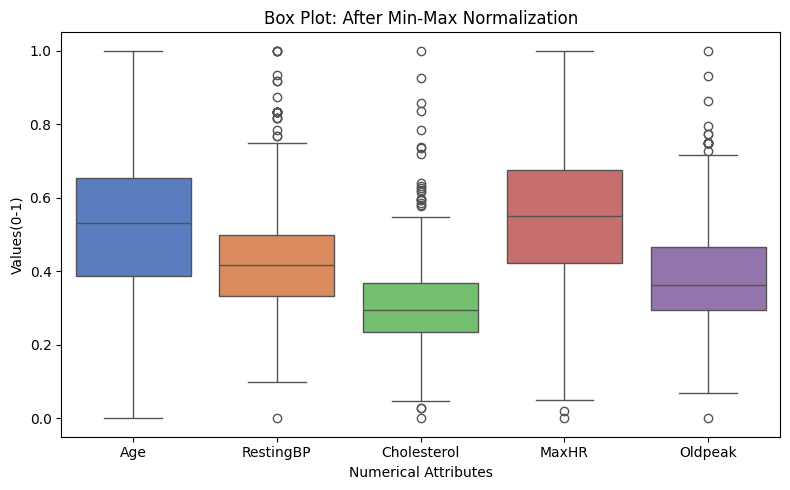

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_minmax[features],palette='muted')
plt.title("Box Plot: After Min-Max Normalization")
plt.xlabel("Numerical Attributes")
plt.ylabel("Values(0-1)")
plt.tight_layout()
plt.show()

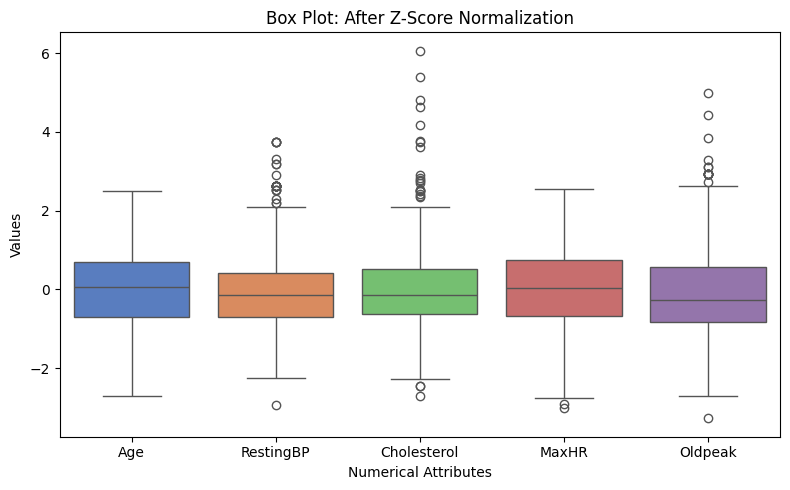

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_zscore[features],palette='muted')
plt.title("Box Plot: After Z-Score Normalization")
plt.xlabel("Numerical Attributes")
plt.ylabel("Values")
plt.tight_layout()
plt.show()

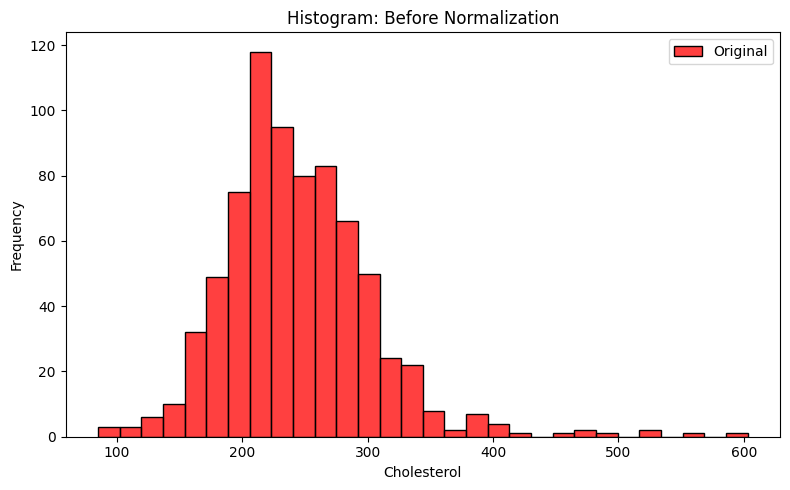

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Cholesterol'],bins=30,color='Red',label='Original')
plt.title("Histogram: Before Normalization")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

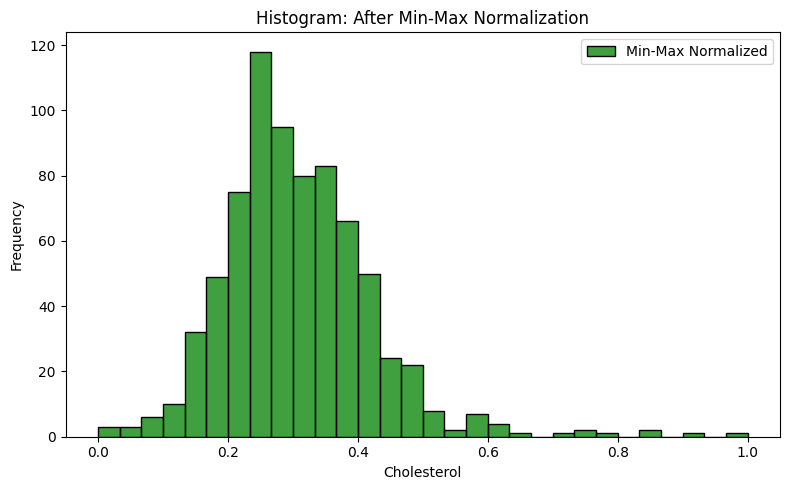

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df_minmax['Cholesterol'],bins=30,color='Green',label='Min-Max Normalized')
plt.title("Histogram: After Min-Max Normalization")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

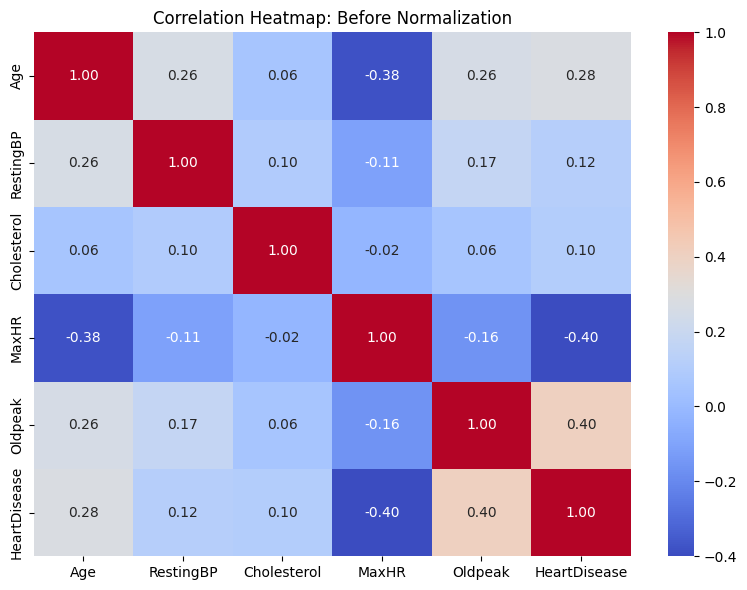

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[features+['HeartDisease']].corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap: Before Normalization")
plt.tight_layout()
plt.show()